In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt

import src.device as device
import src.plotting as plotter
from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.HGPCode import HGPCode
from src.QECCode import TestCode

In [2]:
code_hgp = HGPCode.simplex_code(r=3)

num_qubits = len(code_hgp.data_indices + code_hgp.X_ancilla_indices + code_hgp.Z_ancilla_indices)
s = int(np.sqrt(len(code_hgp.data_indices)//2))
available_coords = set((x,y) for x in range(1, 2*s+1) for y in range(1, s+1))
data_coords_hgp = {}
for i,d in enumerate(code_hgp.data_indices):
    # coords = min(available_coords, key=lambda c: (c[0] - s/2)**2 + (c[1] - s/2)**2)
    # data_coords_hgp[d] = coords
    # available_coords.remove(coords)
    if d < s**2:
        data_coords_hgp[d] = (d//s+1, d%s+1)
    else:
        dd = d-s**2
        data_coords_hgp[d] = (s + dd%s+1, dd//s+1)

dev = device.UnitCellDevice(2*s+2, s+2, device.hardware_params(1e-3))

sched = dev.compile_QEC_schedule(
    code_hgp,
    data_coords_hgp,
    [],
    rounds=1,
    use_highways=True,
    refocus_shuttle_noise=False,
    optimize_ancilla_start=True,
)

8
8
[98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195]
Optimizing 98 ancilla schedules..................................................................................................

(0.0, 9.0)

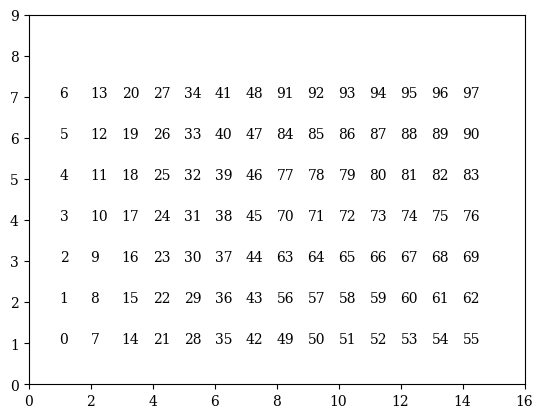

In [3]:
for i,c in data_coords_hgp.items():
    plt.text(c[0], c[1], str(i))
plt.xlim(0, 2*s+2)
plt.ylim(0, s+2)

Need ancilla qubits to be able to decide when and where they start the schedule. Maybe allow free move-anywhere-and-wait action that would be used to set the initialization spot? The wait would be allowed even in a blocked interval, but the end of the wait is an initialization that must be in an available interval.

Also need to let CX order be free



In [4]:
sched.total_duration()

29000

Issue at t=17000
	Overlapping: [100, 115] at pos (0.6, 2.8)
	Overlapping: [100, 115] at pos (0.6, 2.8)
Issue at t=17050
	Overlapping: [100, 115] at pos (0.6, 2.8)
	Overlapping: [100, 115] at pos (0.6, 2.8)
Issue at t=17100
	Overlapping: [100, 115] at pos (0.6, 2.8)
	Overlapping: [100, 115] at pos (0.6, 2.8)
Issue at t=17150
	Overlapping: [100, 115] at pos (0.6, 2.8)
	Overlapping: [100, 115] at pos (0.6, 2.8)
Issue at t=17200
	Overlapping: [100, 115] at pos (0.6, 2.8)
	Overlapping: [100, 115] at pos (0.6, 2.8)
Issue at t=17250
	Overlapping: [100, 115] at pos (0.6, 2.8)
	Overlapping: [100, 115] at pos (0.6, 2.8)
Issue at t=17300
	Overlapping: [100, 115] at pos (0.6, 2.8)
	Overlapping: [100, 115] at pos (0.6, 2.8)
Issue at t=17350
	Overlapping: [100, 115] at pos (0.6, 2.8)
	Overlapping: [100, 115] at pos (0.6, 2.8)
Issue at t=18000
	Overlapping: [137, 140] at pos (12.6, 5.8)
	Overlapping: [137, 140] at pos (12.6, 5.8)
Issue at t=18050
	Overlapping: [137, 140] at pos (12.6, 5.8)
	Overlappi

MovieWriter imagemagick unavailable; using Pillow instead.


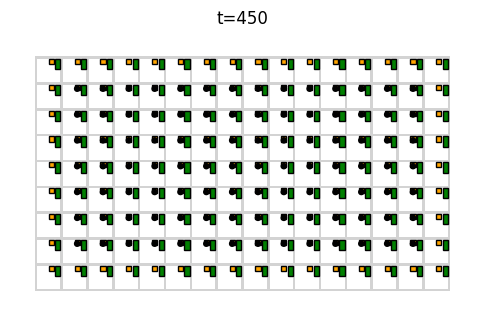

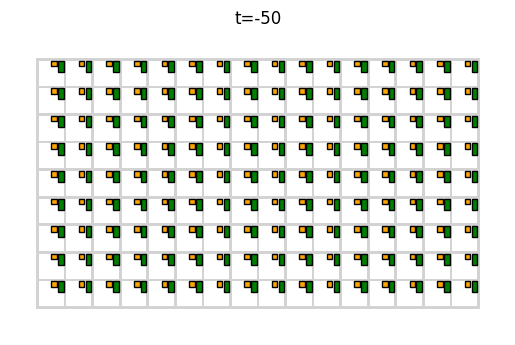

In [5]:
frames = sched.get_frames(50)
plotter.plot_device_snapshot(dev, code_hgp, frames[10])
anim = plotter.animate_device(dev, code_hgp, frames, 'anim_simplex.gif', fps=10)

NameError: name 'codes' is not defined